In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.ops import linemerge, split
from shapely.geometry import Point, MultiPoint, LineString, MultiLineString, GeometryCollection

In [ ]:
road_labels = ['ST_FULLNAM','SHAPE_Leng','CE_SPEED_L', 'geometry']

roads = gpd.read_file("Loudoun_Street_Centerline.shp")    # Load R
roads = roads[roads['CE_SPEED_L'] > 25]
roads = roads[road_labels]

roads.head(10)

# Networkx

,ST_FULLNAM,SHAPE_Leng,CE_SPEED_L,geometry
63,DULLES ACCESS RD,565.042909,35,"LINESTRING (11783123.317 7033735.227, 11783122..."
64,DULLES ACCESS RD,1047.800338,35,"LINESTRING (11783206.598 7034289.374, 11783213..."
65,DULLES ACCESS RD,1848.818768,55,"LINESTRING (11784592.649 7035245.832, 11784675..."
66,DULLES ACCESS RD,366.912467,35,"LINESTRING (11783055.903 7034398.988, 11783088..."
67,DULLES ACCESS RD,762.294505,35,"LINESTRING (11783213.319 7034729.794, 11783229..."
68,DULLES ACCESS RD,702.373027,55,"LINESTRING (11783923.6 7035043.968, 11783936.0..."
69,DULLES ACCESS RD,818.404776,55,"LINESTRING (11783802.322 7035231.898, 11783946..."
70,DULLES ACCESS RD,665.489696,35,"LINESTRING (11783184.215 7033028.21, 11783166...."
71,DULLES ACCESS RD,1316.785021,35,"LINESTRING (11782454.812 7032755.779, 11782495..."
72,DULLES ACCESS RD,668.889262,35,"LINESTRING (11783031.346 7033735.07, 11783030...."


In [4]:
# Add intersections and endpoints together. 



roads = roads.dissolve(by="ST_FULLNAM").reset_index()


sindex = roads.sindex #RTree
intersections_dict = {'geometry': []}   # Points with no features, just geometry
segments_list = []                      

# Get interections
for idx, entry in roads.iterrows():
    geom = entry['geometry']
    st_name = entry['ST_FULLNAM']
        
    #If a street is not continuous, merge them into one geometry
    if isinstance(geom, MultiLineString):
        geom = linemerge(geom)

    # Use spatial index to check which streets are in its bounding box        
    matches_idx = list(sindex.intersection(geom.bounds))
    matches = roads.iloc[matches_idx]
    
    # Get all other streets and merge them
    other_roads = matches[matches['ST_FULLNAM'] != st_name].geometry.union_all()
    inters = geom.intersection(other_roads)
    # Returns POINT (1 intersection), MULTIPOINT (2+), GEOMETRYCOLLECTION (EMPTY), LINE (ignore) 
    
    # Store intersections
    if isinstance(inters, Point):
        intersections_dict['geometry'].append(inters)
    elif isinstance(inters, MultiPoint):
        intersections_dict['geometry'].extend(inters.geoms)   # For 1 multipoint of X points, it adds X points. 
    else:
        continue

    # Once we found intersections for this street, split it by the intersections
    # if inters.is_empty: # 0 intersections
    #     line_segments = [geom]
    # else:                
    line_segments = list(split(geom, inters).geoms)

    for segment in line_segments:
        segment_dict = entry.to_dict()  # temporary dict
        segment_dict['geometry'] = segment
        segments_list.append(segment_dict)
    
    # Now add any endpoints the segment may have.
        endpoints = [Point(segment.coords[0]), Point(segment.coords[-1])]
        for endpoint in endpoints:
            intersections_dict['geometry'].append(endpoint)
    
    
    
    
    
intersections = gpd.GeoDataFrame(intersections_dict, geometry='geometry', crs=roads.crs)
road_segments = gpd.GeoDataFrame(segments_list, geometry='geometry', crs=roads.crs)
road_segments["seg_id"] = road_segments.index.astype(str)
intersections["intersection_idx"] = intersections.reset_index().index

print(len(road_segments))
print(len(intersections))

intersections = intersections.drop_duplicates(subset=['geometry'])
intersections = intersections.reset_index(drop=True)
intersections["intersection_idx"] = intersections.index

print(f"Unique intersections: {len(intersections)}")


3384
10033
Unique intersections: 2305


In [5]:
# Spatially join intersections and roads to find which roads intersect.
# buffer

road_segments = road_segments.to_crs(epsg=4326)
intersections = intersections.to_crs(epsg=4326)
# Shows what streets intersect with each point. 
road_groups = gpd.sjoin(
    intersections,  # points
    road_segments,          # lines
    how="left",     
    predicate="intersects"
).drop_duplicates()
road_groups.head(10)
#intersections.head(10)

,geometry,intersection_idx,index_right,ST_FULLNAM,SHAPE_Leng,CE_SPEED_L,seg_id
0,POINT (-77.76858 39.12981),0,1435.0,LEESBURG PIKE,1580.529368,55.0,1435
0,POINT (-77.76858 39.12981),0,0.0,AIRMONT RD,7210.650010,45.0,0
0,POINT (-77.76858 39.12981),0,1436.0,LEESBURG PIKE,1580.529368,55.0,1436
1,POINT (-77.76864 39.12957),1,1464.0,LEESBURG PIKE,1580.529368,55.0,1464
1,POINT (-77.76864 39.12957),1,1.0,AIRMONT RD,7210.650010,45.0,1
1,POINT (-77.76864 39.12957),1,0.0,AIRMONT RD,7210.650010,45.0,0
1,POINT (-77.76864 39.12957),1,1465.0,LEESBURG PIKE,1580.529368,55.0,1465
2,POINT (-77.80953 39.05771),2,6.0,AIRMONT RD,7210.650010,45.0,6
2,POINT (-77.80953 39.05771),2,5.0,AIRMONT RD,7210.650010,45.0,5
2,POINT (-77.80953 39.05771),2,918.0,EBENEZER CHURCH RD,7384.054427,35.0,918


In [ ]:
# Get a week of crash locations, for each location find the nearest node and aggregate it into
# the intersections_dict. 

crashes = pd.read_csv('loudoun_county.csv')
crashes['geometry'] = crashes.apply(lambda row:Point(row['x'], row['y']), axis=1)
# 4326
crashes = gpd.GeoDataFrame(crashes, geometry='geometry', crs='EPSG:4326')

crashes = crashes.to_crs(epsg=2284)
intersections = intersections.to_crs(crashes.crs)
# # 
# Use a buffer to join. 
nearest = gpd.sjoin_nearest(
    crashes, # left
    intersections, # right
    how='left',
    distance_col='dist_to_node')

print(len(nearest))
nearest.head(10)

C:\Users\liamm\AppData\Local\Temp\ipykernel_5440\25051871.py:4: DtypeWarning: Columns (116,118) have mixed types. Specify dtype option on import or set low_memory=False.
  crashes = pd.read_csv('loudoun_county.csv')


21210


,Unnamed: 0,OBJECTID_x,Document_Nbr,Crash Year,Crash Date,Crash Military Time,Crash Severity,K_People,A_People,B_People,...,Ped_Cond,Ped_Al_Test,Ped_Drug,Ped_Rflct,Local Case CD,Route or Street Name,geometry,index_right,intersection_idx,dist_to_node
0,38,39,173155071,2017,11/10/2017 5:00:00 AM,747.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170020796,ST LOUIS RD,POINT (11685023.483 4254554.381),2000,2000,1101.620889
1,68,69,170915202,2017,3/31/2017 4:00:00 AM,1646.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170005674,ROUTE 7,POINT (11800093.253 4261537.602),1443,1443,224.234698
2,126,127,173405162,2017,12/6/2017 5:00:00 AM,837.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170022629,WAXPOOL RD,POINT (11783221.401 4256039.439),1804,1804,209.071156
3,168,169,171285600,2017,4/29/2017 4:00:00 AM,1352.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170007454,ALGONKIAN PARKWAY,POINT (11799429.543 4272381.372),47,47,858.933924
4,181,182,172275173,2017,8/15/2017 4:00:00 AM,1105.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170014700,WAXPOOL ROAD RAMP,POINT (11785612.361 4254303.85),2056,2056,118.812823
5,261,262,171325114,2017,5/11/2017 4:00:00 AM,1455.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170008363,43300 SOUTHER WALK PLZ,POINT (11766195.3 4256346.905),1676,1676,385.434253
6,272,273,170105326,2017,1/10/2017 5:00:00 AM,800.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170000573,BRADDOCK RD,POINT (11754690.307 4220497.464),414,414,204.971475
7,275,276,173245567,2017,9/30/2017 4:00:00 AM,2150.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170017923,ALGONKIAN PARKWAY,POINT (11789148.085 4269901.345),43,43,55.886591
8,374,375,172065274,2017,7/25/2017 4:00:00 AM,1442.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,SO170013335,MOUNTAIN RD,POINT (11708788.727 4332065.53),1453,1453,519.228410
9,429,330492,190465212,2019,2/15/2019 5:00:00 AM,1047.0,A,0.0,3.0,0.0,...,NaN,NaN,NaN,NaN,SO190003048,RYAN RD,POINT (11762168.33 4249360.189),591,591,7.084790


In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add intersection/endpoint nodes to the Graph. 
# However, this preserves only geometric info, we need to snap crash locations to the nearest intersection. 
# There will be a step before this. 

for idx, intersection in intersections.iterrows():
    node_id = intersection['intersection_idx']
    node_attributes = intersection.to_dict()
    G.add_node(node_id, pos=(intersection.geometry.x, intersection.geometry.y), **node_attributes)

In [8]:
# Add Edges to our graph
# iterate over the road segments

for seg_id in road_segments['seg_id'].unique():
    # To get the node ids that connect this segment, 
    connecting_intersections = road_groups[road_groups['seg_id'] == seg_id]['intersection_idx'].tolist()
    print(f"Segment {seg_id}: connected: {connecting_intersections}")
    if(len(connecting_intersections) == 2):
        node1 = connecting_intersections[0]
        node2 = connecting_intersections[1]
        seg_data = road_segments[road_segments['seg_id'] == seg_id].iloc[0]
        G.add_edge(node1, node2, seg_id=seg_id,
                  street_name=seg_data['ST_FULLNAM'],
                  speed_limit=seg_data['CE_SPEED_L'],
                  length=seg_data.geometry.length,
                  geometry=seg_data.geometry)

Segment 0: connected: [0, 1]
Segment 1: connected: [1, 4]
Segment 2: connected: [4, 5]
Segment 3: connected: [3, 5]
Segment 4: connected: [3, 6]
Segment 5: connected: [2, 6]
Segment 6: connected: [2, 7]
Segment 7: connected: [7, 8]
Segment 8: connected: [8, 9]
Segment 9: connected: [12, 13]
Segment 10: connected: [13, 14]
Segment 11: connected: [11, 14]
Segment 12: connected: [10, 11]
Segment 13: connected: [15, 16]
Segment 14: connected: [18, 19]
Segment 15: connected: [17, 18]
Segment 16: connected: [22, 23]
Segment 17: connected: [22, 24]
Segment 18: connected: [24, 26]
Segment 19: connected: [26, 27]
Segment 20: connected: [27, 28]
Segment 21: connected: [21, 28]
Segment 22: connected: [21, 25]
Segment 23: connected: [25, 30]
Segment 24: connected: [30, 32]
Segment 25: connected: [32, 33]
Segment 26: connected: [31, 33]
Segment 27: connected: [20, 31]
Segment 28: connected: [20, 34]
Segment 29: connected: [34, 37]
Segment 30: connected: [39, 40]
Segment 31: connected: [40, 41]
Segm

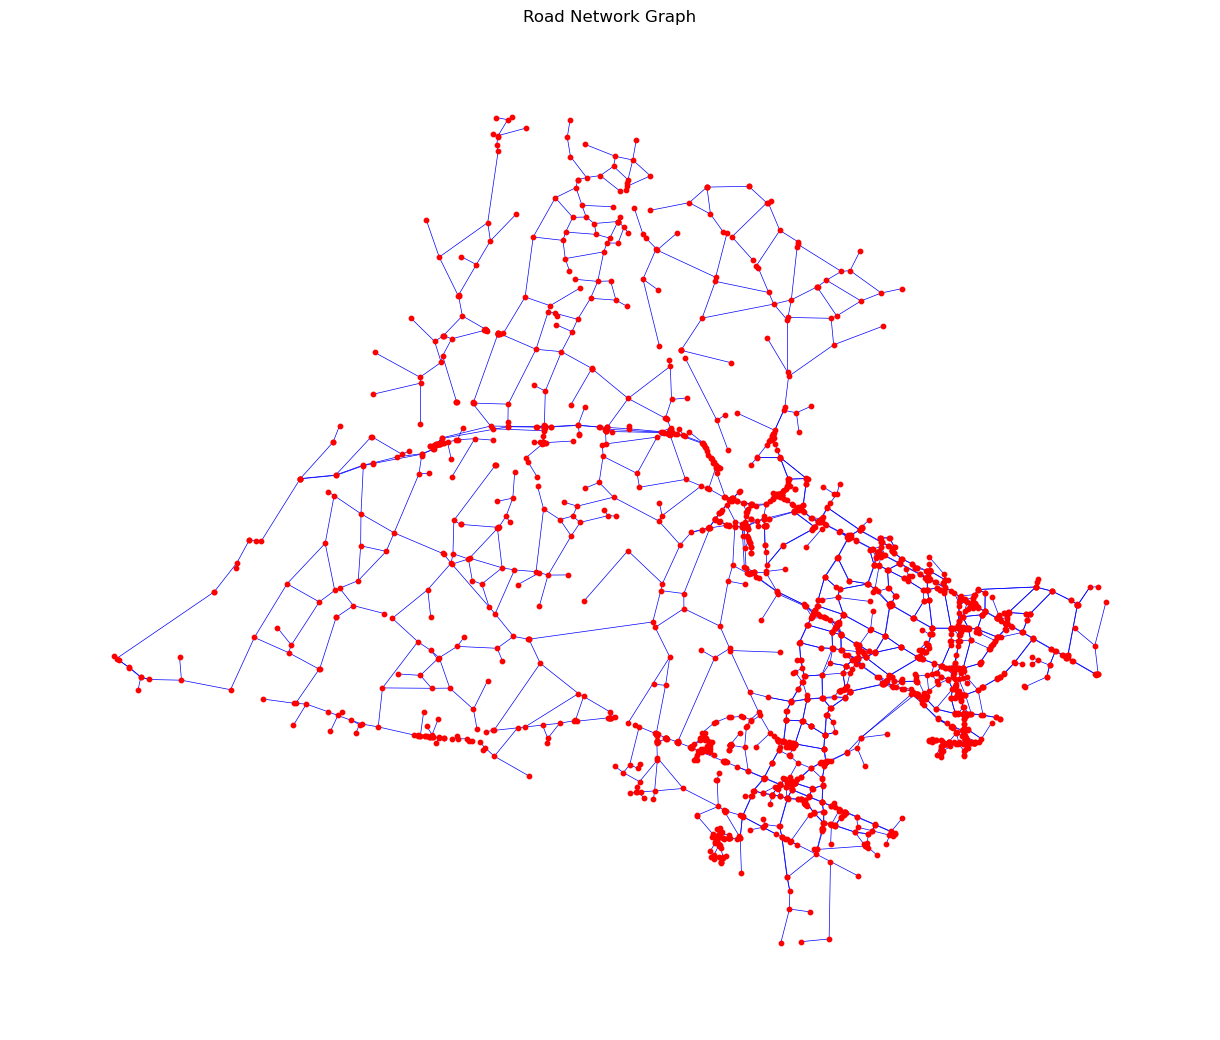

In [9]:

# Get node positions from the graph
pos = nx.get_node_attributes(G, "pos")

# Basic draw
plt.figure(figsize=(12, 10))
nx.draw(G, pos=pos, with_labels=False, node_size=10, node_color='red', 
        edge_color='blue', width=0.5)
plt.title("Road Network Graph")
plt.show()

In [10]:
## After building NetworkX graph Nodes (N) and Edges (E), get one snapshot of the graph and run it through GNN PytorchGeometric. 
# This will be on a different notebook

# The notebook will also include dynamic aggregated crash data to compare it with performance on static road data only. 
# Also needs to be a pipeline for inputting any county name, and it trains a model with the crashes in that county. 

# We also need to do MCA on categorie indicators (between the column itself)


In [11]:
import numpy as np
from IPython.display import display

m =road_segments.explore(
    column="seg_id",
    categorical=True,
    tooltip=True,
    legend=False
)
intersections.explore(
    m=m,
    marker_type="circle",
    tooltip=True,
    marker_kwds={
        "radius": 8, 
        "fill": True, 
        "fillColor": "black", 
        "fillOpacity": 1,
        "color":"black"}
)
midpoint
#midpoints.explore(m=m, tooltip=True)
m.save("intersections.html")

NameError: name 'midpoint' is not defined